# 01 — Data Pipeline

This notebook builds the reproducible data layer for the project.

The goal is not to optimize a strategy yet. The goal is to create a clean and auditable market data panel that will be reused by all downstream notebooks:

1. regime detection,
2. regime-conditioned risk estimation,
3. allocation backtesting,
4. SMDP-inspired stress-state policy analysis.

The notebook follows the project design principle:

> notebooks are visual research interfaces; reusable logic lives in `src/regime_portfolio`.

Expected local outputs:

- `data/processed/prices.csv`
- `data/processed/returns.csv`
- `data/processed/risk_features.csv`
- `reports/figures/01_normalized_prices.png`
- `reports/figures/01_feature_panel.png`

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow the notebook to run both after `pip install -e .` and directly from the repo.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
from regime_portfolio.data import DataConfig, compute_returns, load_price_panel
from regime_portfolio.features import FeatureConfig, make_feature_panel

## 1. Market universe and data conventions

The default universe is deliberately simple and liquid:

| Ticker | Role |
|---|---|
| SPY | US equities |
| TLT | long-duration US Treasuries |
| IEF | intermediate US Treasuries |
| GLD | gold |
| DBC | broad commodities |
| UUP | US dollar |
| SHY | short Treasuries / defensive proxy |

This is not meant to be a final institutional universe. It is a controlled public-data universe for demonstrating the research pipeline.

In [3]:
config = DataConfig(
    tickers=("SPY", "TLT", "IEF", "GLD", "DBC", "UUP", "SHY"),
    start="2007-01-01",
    end=None,
    source="yfinance",
)

config

DataConfig(tickers=('SPY', 'TLT', 'IEF', 'GLD', 'DBC', 'UUP', 'SHY'), start='2007-01-01', end=None, source='yfinance')

## 2. Download price data

The project currently uses public ETF prices. This is convenient for a transparent GitHub research project, but the data source should be treated as a research input rather than a production-grade market data feed.

The key reproducibility rule is simple:

> downstream notebooks should read the processed CSV files produced here, not download their own inconsistent data panels.

In [4]:
prices_raw = load_price_panel(config)

print(f"Raw price panel shape: {prices_raw.shape}")
display(prices_raw.tail())

Raw price panel shape: (4890, 7)


Ticker,DBC,GLD,IEF,SHY,SPY,TLT,UUP
Date,,,,,,,
2026-06-04,29.8800,411.2700,94.1200,82.0300,757.0900,85.5000,27.8400
2026-06-05,29.2300,396.2400,93.6200,81.8600,737.5500,85.0600,28.0200
2026-06-08,29.4700,397.2700,93.5200,81.9000,739.2200,84.6200,28.0300
2026-06-09,29.0700,390.7800,93.7800,81.9400,737.0500,85.1200,28.0100
2026-06-10,29.1700,374.5800,93.6900,81.9400,725.4300,84.8800,28.0500


## 3. Basic data quality checks

Before computing returns, we inspect:

- date range,
- missing values,
- available tickers,
- first and last valid observations.

The purpose is to make data issues visible early rather than hiding them inside the backtest.

In [5]:
data_quality = pd.DataFrame(
    {
        "first_valid_date": prices_raw.apply(lambda x: x.first_valid_index()),
        "last_valid_date": prices_raw.apply(lambda x: x.last_valid_index()),
        "missing_count": prices_raw.isna().sum(),
        "missing_pct": prices_raw.isna().mean(),
    }
)

display(data_quality)

,first_valid_date,last_valid_date,missing_count,missing_pct
Ticker,,,,
DBC,2007-01-03,2026-06-10,0,0.0000
GLD,2007-01-03,2026-06-10,0,0.0000
IEF,2007-01-03,2026-06-10,0,0.0000
SHY,2007-01-03,2026-06-10,0,0.0000
SPY,2007-01-03,2026-06-10,0,0.0000
TLT,2007-01-03,2026-06-10,0,0.0000
UUP,2007-03-01,2026-06-10,39,0.0080


## 4. Clean the price panel

We use a conservative cleaning convention:

1. sort the date index,
2. remove rows where all assets are missing,
3. forward-fill short gaps,
4. keep only rows where all selected assets are available.

This creates a common trading calendar for all assets. That is useful for this first research version because regime features, correlations, and allocation weights all need aligned observations.

In [6]:
prices = (
    prices_raw
    .sort_index()
    .dropna(how="all")
    .ffill()
    .dropna(how="any")
)

print(f"Clean price panel shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
display(prices.tail())

Clean price panel shape: (4851, 7)
Date range: 2007-03-01 to 2026-06-10


Ticker,DBC,GLD,IEF,SHY,SPY,TLT,UUP
Date,,,,,,,
2026-06-04,29.8800,411.2700,94.1200,82.0300,757.0900,85.5000,27.8400
2026-06-05,29.2300,396.2400,93.6200,81.8600,737.5500,85.0600,28.0200
2026-06-08,29.4700,397.2700,93.5200,81.9000,739.2200,84.6200,28.0300
2026-06-09,29.0700,390.7800,93.7800,81.9400,737.0500,85.1200,28.0100
2026-06-10,29.1700,374.5800,93.6900,81.9400,725.4300,84.8800,28.0500


## 5. Compute daily log returns

The project uses log returns as the default convention. Log returns are convenient for cumulative performance diagnostics because cumulative log returns exponentiate into a wealth index.

This notebook only prepares returns. It does not decide whether a trading rule is good.

In [7]:
returns = compute_returns(prices, method="log", dropna=True)

print(f"Return panel shape: {returns.shape}")
display(returns.describe().T)

Return panel shape: (4850, 7)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
DBC,"4,850.0000",0.0001,0.0121,-0.0828,-0.0062,0.0007,0.0067,0.0665
GLD,"4,850.0000",0.0004,0.0114,-0.1084,-0.0051,0.0006,0.0062,0.1070
IEF,"4,850.0000",0.0001,0.0044,-0.0254,-0.0025,0.0002,0.0027,0.0337
SHY,"4,850.0000",0.0001,0.0010,-0.0066,-0.0004,0.0000,0.0005,0.0099
SPY,"4,850.0000",0.0004,0.0124,-0.1159,-0.0041,0.0007,0.0060,0.1356
TLT,"4,850.0000",0.0001,0.0095,-0.0690,-0.0056,0.0004,0.0057,0.0725
UUP,"4,850.0000",0.0001,0.0051,-0.0386,-0.0028,0.0000,0.0029,0.0398


## 6. Build interpretable regime features

The first version of the project uses a compact feature set:

- realized volatility of the equity proxy,
- rolling drawdown of the equity proxy,
- rolling average cross-asset correlation,
- equity momentum,
- downside semivolatility.

These features are intentionally interpretable. The goal is not to maximize classification accuracy, but to produce economically meaningful stress states that can be audited.

In [8]:
feature_config = FeatureConfig(
    vol_window=21,
    corr_window=63,
    drawdown_window=252,
    momentum_window=63,
    annualization=252,
    equity_proxy="SPY",
)

risk_features = make_feature_panel(
    prices=prices,
    returns=returns,
    config=feature_config,
)

print(f"Feature panel shape: {risk_features.shape}")
display(risk_features.tail())

Feature panel shape: (4788, 5)


,SPY_realized_vol,SPY_drawdown,avg_corr,SPY_momentum,SPY_downside_semivol
Date,,,,,
2026-06-04,0.0965,-0.0033,0.0973,0.1143,0.0763
2026-06-05,0.1294,-0.0290,0.1136,0.0999,0.0872
2026-06-08,0.1290,-0.0268,0.1140,0.0928,0.0872
2026-06-09,0.1263,-0.0296,0.1145,0.0914,0.0872
2026-06-10,0.1373,-0.0449,0.1172,0.0755,0.0909


## 7. Visual check — normalized prices

This figure is a data sanity check, not a performance claim.

It shows the growth of one dollar invested in each ETF at the beginning of the cleaned sample. Large differences across assets are expected because the universe mixes equities, bonds, gold, commodities, USD, and short Treasuries.

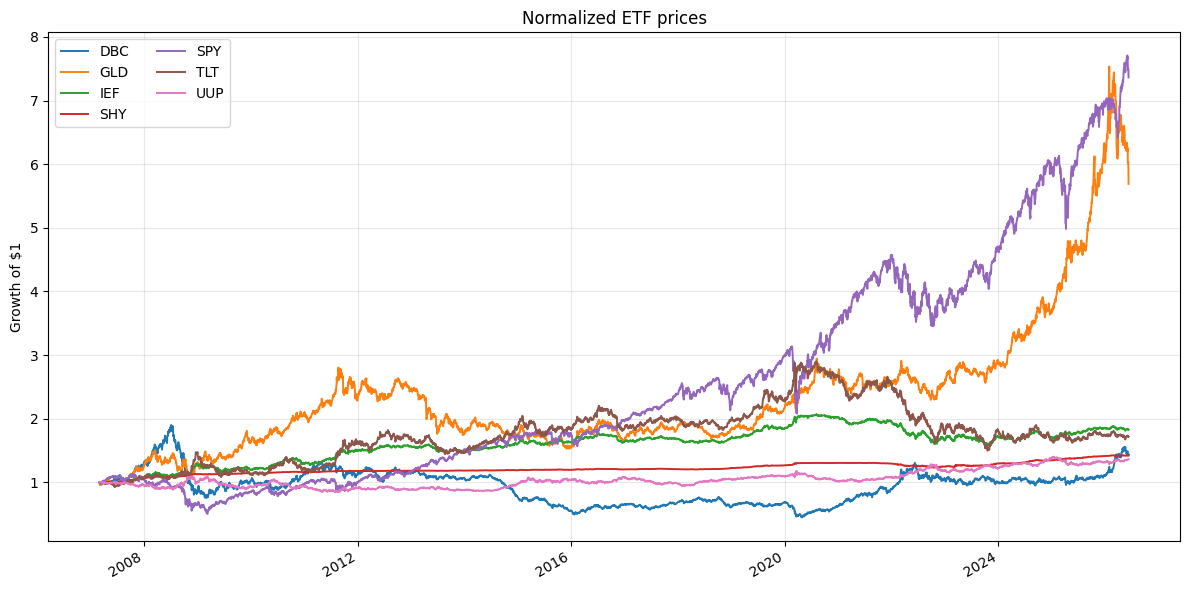

In [9]:
normalized_prices = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
normalized_prices.plot(ax=ax, linewidth=1.4)

ax.set_title("Normalized ETF prices")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncols=2)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_normalized_prices.png", dpi=150)
plt.show()

## 8. Visual check — regime feature panel

The next plot checks whether the constructed features behave plausibly over time. In particular, stress-related features should move during known crisis windows, but the notebook does not manually label or hard-code crisis periods.

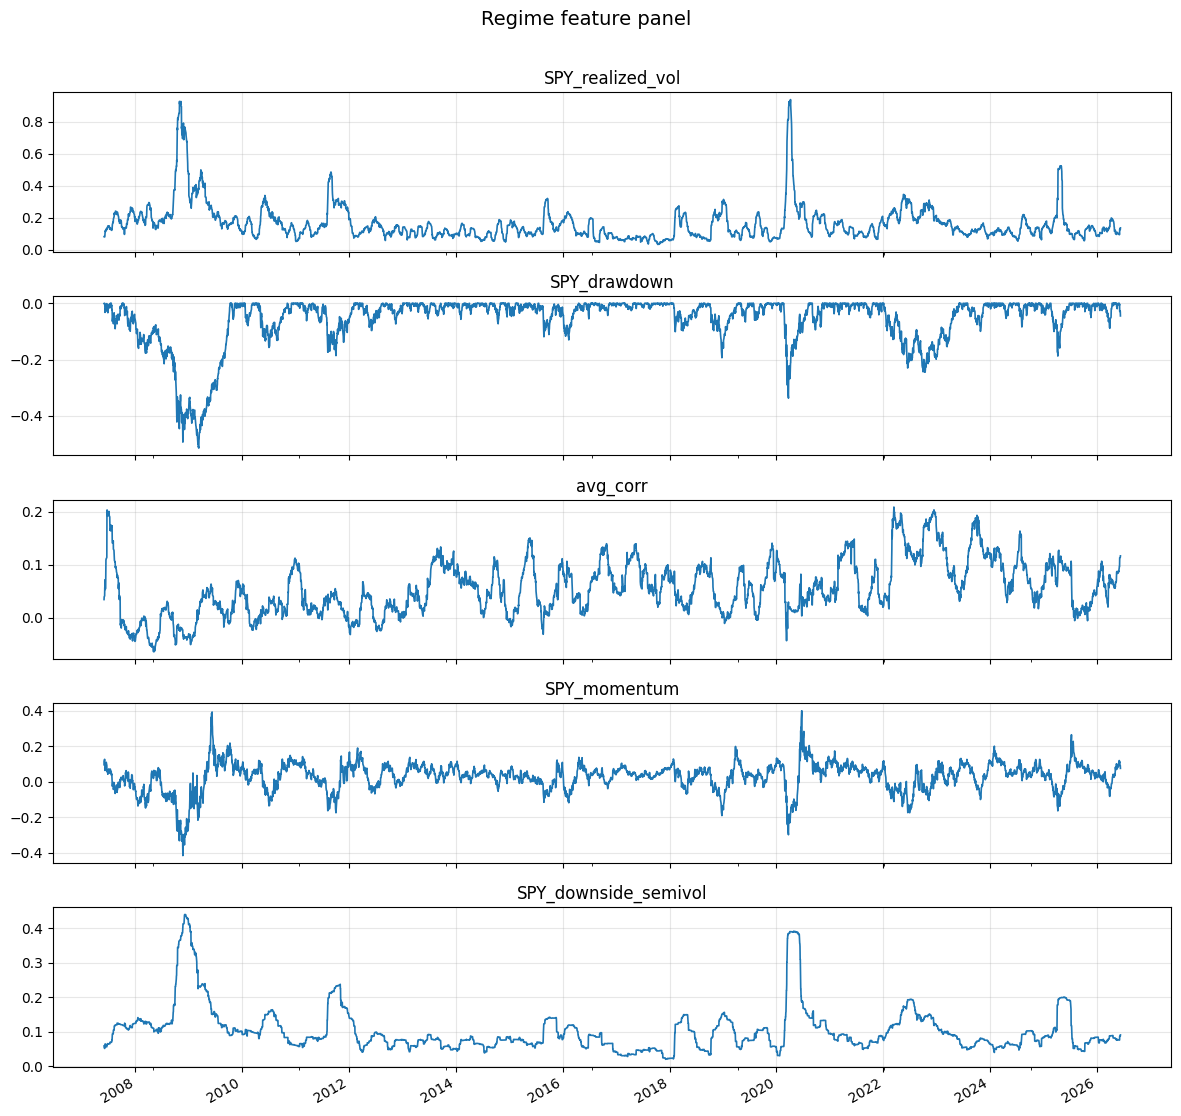

In [10]:
feature_plot = risk_features.copy()

fig, axes = plt.subplots(
    nrows=len(feature_plot.columns),
    ncols=1,
    figsize=(12, 2.2 * len(feature_plot.columns)),
    sharex=True,
)

if len(feature_plot.columns) == 1:
    axes = [axes]

for ax, column in zip(axes, feature_plot.columns):
    feature_plot[column].plot(ax=ax, linewidth=1.2)
    ax.set_title(column)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("")

fig.suptitle("Regime feature panel", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_feature_panel.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export processed data

All downstream notebooks should read these exported files.

This keeps the project pipeline coherent:

```text
01_data_pipeline
  -> prices.csv
  -> returns.csv
  -> risk_features.csv

In [11]:
prices.to_csv(DATA_DIR / "prices.csv")
returns.to_csv(DATA_DIR / "returns.csv")
risk_features.to_csv(DATA_DIR / "risk_features.csv")

print("Saved:")
print(DATA_DIR / "prices.csv")
print(DATA_DIR / "returns.csv")
print(DATA_DIR / "risk_features.csv")

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/prices.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/returns.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/risk_features.csv


## 10. Notebook takeaway

This notebook creates the common data layer for the project.

Main outputs:

- a cleaned cross-asset price panel,
- a daily log-return panel,
- an interpretable regime-feature panel.

The next notebook uses these features to estimate latent market regimes. At this stage, no allocation rule has been evaluated and no performance claim has been made.